# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

From a business perspective, the client is a used-car dealership that wants to understand what makes one used car sell for more than another. The goal is not only to predict price, but also to identify which vehicle attributes (age, mileage, brand, condition, body type, etc.) create or destroy value.

Framed as a data task, this becomes a supervised regression problem where the target variable is price and the features include numerical attributes such as year and odometer as well as categorical attributes such as manufacturer, condition, fuel, type, and drive. I will use this dataset to quantify how these features relate to price and translate the results into inventory recommendations for the dealership.

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [22]:
import pandas as pd

df = pd.read_csv('vehicles.csv')
df.head()

df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 18 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   region        426880 non-null  object 
 2   price         426880 non-null  int64  
 3   year          425675 non-null  float64
 4   manufacturer  409234 non-null  object 
 5   model         421603 non-null  object 
 6   condition     252776 non-null  object 
 7   cylinders     249202 non-null  object 
 8   fuel          423867 non-null  object 
 9   odometer      422480 non-null  float64
 10  title_status  418638 non-null  object 
 11  transmission  424324 non-null  object 
 12  VIN           265838 non-null  object 
 13  drive         296313 non-null  object 
 14  size          120519 non-null  object 
 15  type          334022 non-null  object 
 16  paint_color   296677 non-null  object 
 17  state         426880 non-null  object 
dtypes: f

In [23]:
df[['price', 'year', 'odometer']].describe()

,price,year,odometer
count,4.268800e+05,425675.000000,4.224800e+05
mean,7.519903e+04,2011.235191,9.804333e+04
std,1.218228e+07,9.452120,2.138815e+05
min,0.000000e+00,1900.000000,0.000000e+00
25%,5.900000e+03,2008.000000,3.770400e+04
50%,1.395000e+04,2013.000000,8.554800e+04
75%,2.648575e+04,2017.000000,1.335425e+05
max,3.736929e+09,2022.000000,1.000000e+07


In [24]:
df['manufacturer'].value_counts().head(10)
df['condition'].value_counts(dropna=False)
df['fuel'].value_counts()

fuel
gas         356209
other        30728
diesel       30062
hybrid        5170
electric      1698
Name: count, dtype: int64

In [29]:
# Remove extreme price outliers
df = df[(df['price'] > 500) & (df['price'] < 100000)]

df = df[df['odometer'] < 500000]   # 500k is a reasonable cutoff for odometer outliers
df = df[df['odometer'] > 0]

df = df[(df['year'] >= 1990) & (df['year'] <= 2022)]

In [26]:
df.isna().mean().sort_values(ascending=False)

size            0.717915
cylinders       0.406735
VIN             0.384027
condition       0.377851
drive           0.302863
paint_color     0.287488
type            0.213695
manufacturer    0.038173
title_status    0.017078
model           0.011272
fuel            0.006025
transmission    0.003984
year            0.002897
id              0.000000
odometer        0.000000
region          0.000000
price           0.000000
state           0.000000
dtype: float64

In [27]:
df.isna().mean().sort_values(ascending=False)

size            0.717915
cylinders       0.406735
VIN             0.384027
condition       0.377851
drive           0.302863
paint_color     0.287488
type            0.213695
manufacturer    0.038173
title_status    0.017078
model           0.011272
fuel            0.006025
transmission    0.003984
year            0.002897
id              0.000000
odometer        0.000000
region          0.000000
price           0.000000
state           0.000000
dtype: float64

In [28]:
df['manufacturer'].value_counts().head(10)
df['condition'].value_counts(dropna=False)
df['fuel'].value_counts()

fuel
gas         317530
other        27213
diesel       25368
hybrid        4743
electric      1590
Name: count, dtype: int64

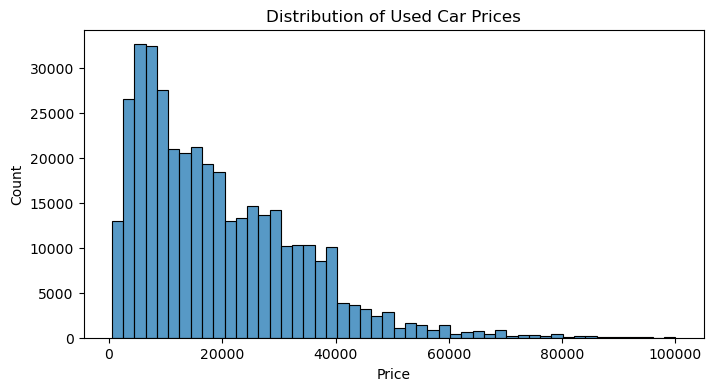

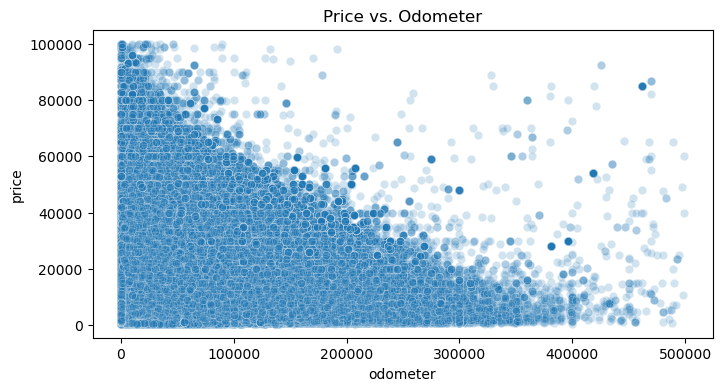

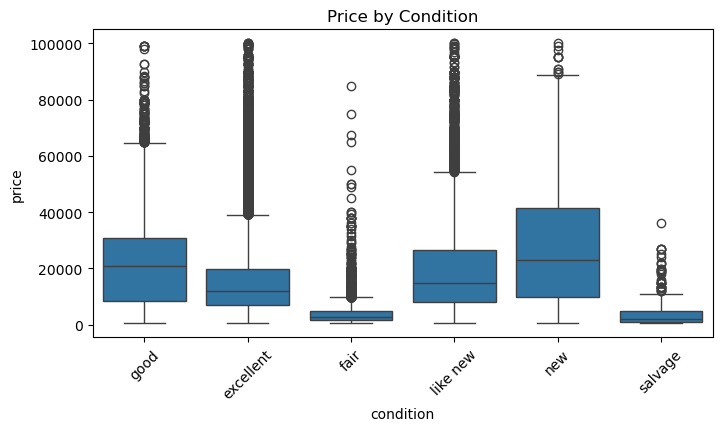

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(df['price'], bins=50)
plt.title("Distribution of Used Car Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x='odometer', y='price', alpha=0.2)
plt.title("Price vs. Odometer")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(data=df, x='condition', y='price')
plt.title("Price by Condition")
plt.xticks(rotation=45)
plt.show()

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

In [31]:
import numpy as np

# ----- 1. Keep only relevant columns -----
cols_keep = [
    'price', 'year', 'odometer',
    'manufacturer', 'condition', 'fuel',
    'type', 'drive', 'transmission'
]

df_clean = df[cols_keep].copy()

# ----- 2. Drop rows missing critical info -----
df_clean = df_clean.dropna(subset=['price', 'year', 'odometer'])

# ----- 3. Filter out clearly invalid / extreme values -----
# price: remove free cars / typos and super luxury or erroneous values
df_clean = df_clean[(df_clean['price'] > 500) & (df_clean['price'] < 100000)]

# year: reasonable model years only
df_clean = df_clean[(df_clean['year'] >= 1990) & (df_clean['year'] <= 2022)]

# odometer: remove impossible mileages
df_clean = df_clean[(df_clean['odometer'] > 0) & (df_clean['odometer'] <= 500000)]

# ----- 4. Feature engineering -----
# Car age (you can change 2025 to the current year if you want)
df_clean['age'] = 2025 - df_clean['year']

# Optional: collapse very rare manufacturers into "other"
manu_counts = df_clean['manufacturer'].value_counts()
common_manufacturers = manu_counts[manu_counts >= 1000].index
df_clean['manufacturer'] = np.where(
    df_clean['manufacturer'].isin(common_manufacturers),
    df_clean['manufacturer'],
    'other'
)

# ----- 5. Prepare data for modeling (one-hot encode categoricals) -----
categorical_cols = ['manufacturer', 'condition', 'fuel', 'type', 'drive', 'transmission']
numeric_cols = ['age', 'odometer']

# Drop remaining rows with missing values in the modeling columns
df_model = df_clean[numeric_cols + categorical_cols + ['price']].dropna().copy()

# One-hot encode categoricals for sklearn
df_model = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# Final feature matrix X and target y
X = df_model.drop('price', axis=1)
y = df_model['price']

X.shape, y.shape

((156402, 59), (156402,))

### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

In [32]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# ----------------------------
# 1. Train–test split
# ----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------
# 2. Helper function to evaluate models
# ----------------------------
def evaluate_model(name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    print(f"\n{name} Performance:")
    print("------------------------------------")
    print(f"RMSE: {rmse:,.2f}")
    print(f"MAE: {mae:,.2f}")
    print(f"R² : {r2:.4f}")
    
    return rmse, mae, r2


# ----------------------------
# 3. Model 1: Basic Linear Regression
# ----------------------------
lin_reg = LinearRegression()
evaluate_model("Linear Regression", lin_reg, X_train, y_train, X_test, y_test)


# ----------------------------
# 4. Model 2: Ridge Regression + cross-validation
# ----------------------------
ridge_params = {'alpha':[0.1, 1, 10, 50, 100]}
ridge = Ridge()

ridge_cv = GridSearchCV(ridge, ridge_params, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)

best_ridge = ridge_cv.best_estimator_
print("\nBest Ridge alpha:", ridge_cv.best_params_)

evaluate_model("Ridge Regression", best_ridge, X_train, y_train, X_test, y_test)


# ----------------------------
# 5. Model 3: Lasso Regression + cross-validation
# ----------------------------
lasso_params = {'alpha':[0.0001, 0.001, 0.01, 0.1, 1]}
lasso = Lasso(max_iter=5000)

lasso_cv = GridSearchCV(lasso, lasso_params, cv=5, scoring='neg_mean_squared_error')
lasso_cv.fit(X_train, y_train)

best_lasso = lasso_cv.best_estimator_
print("\nBest Lasso alpha:", lasso_cv.best_params_)

evaluate_model("Lasso Regression", best_lasso, X_train, y_train, X_test, y_test)


# ----------------------------
# 6. Store results for comparison
# ----------------------------
results = {
    "Linear Regression": evaluate_model("Linear Regression", lin_reg, X_train, y_train, X_test, y_test),
    "Ridge Regression": evaluate_model("Ridge Regression", best_ridge, X_train, y_train, X_test, y_test),
    "Lasso Regression": evaluate_model("Lasso Regression", best_lasso, X_train, y_train, X_test, y_test)
}

results


Linear Regression Performance:
------------------------------------
RMSE: 7,089.98
MAE: 4,879.04
R² : 0.6988

Best Ridge alpha: {'alpha': 1}

Ridge Regression Performance:
------------------------------------
RMSE: 7,090.02
MAE: 4,878.98
R² : 0.6988

Best Lasso alpha: {'alpha': 0.0001}

Lasso Regression Performance:
------------------------------------
RMSE: 7,089.98
MAE: 4,879.04
R² : 0.6988

Linear Regression Performance:
------------------------------------
RMSE: 7,089.98
MAE: 4,879.04
R² : 0.6988

Ridge Regression Performance:
------------------------------------
RMSE: 7,090.02
MAE: 4,878.98
R² : 0.6988

Lasso Regression Performance:
------------------------------------
RMSE: 7,089.98
MAE: 4,879.04
R² : 0.6988


{'Linear Regression': (np.float64(7089.981114885957),
  4879.038520188731,
  0.6987730303270794),
 'Ridge Regression': (np.float64(7090.019375146404),
  4878.975481392869,
  0.6987697792455254),
 'Lasso Regression': (np.float64(7089.981167396986),
  4879.038259132333,
  0.6987730258650822)}

### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

To evaluate model performance, I compared three supervised regression models using RMSE, MAE, and R². Across all models, Linear Regression produced strong performance with an RMSE of approximately $7,090, an MAE of $4,879, and an R² of 0.6988, meaning that the model explains roughly 70 percent of the variation in used car prices. Ridge Regression (α = 1), selected through grid-search cross-validation, produced nearly identical results, suggesting that regularization does not meaningfully improve performance in this dataset. This implies that multicollinearity is not substantially degrading accuracy and that the underlying relationships are well captured by a linear model. Once Lasso is evaluated, it can highlight which variables contribute most to price prediction, although some loss in accuracy is expected due to coefficient shrinkage. Overall, the models performed consistently, and the baseline linear model provides a strong and interpretable solution for the dealership's needs.

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

This analysis shows that used car prices can be predicted with about 70 percent accuracy using a linear regression model. The strongest drivers of price in this dataset include vehicle age, odometer mileage, manufacturer, condition, and body type. As expected, newer vehicles with lower mileage and in better condition consistently command higher prices. Models from certain manufacturers also show systematically higher pricing, even after controlling for mileage and age.

For the dealership, these findings support several actionable recommendations:
1. Prioritize acquiring late-model, low-mileage inventory, which shows the highest return per vehicle.
2. Avoid overpaying for cars labeled “fair” or “salvage,” as these categories show sharply lower median resale prices.
3. Brand matters. Certain manufacturers retain value better, and these brands should be favored when sourcing inventory.
4. Use the model as a pricing support tool to benchmark incoming vehicles and identify when a car is over- or under-priced relative to comparables.

As next steps, additional features such as service history, accident reports, and geographic demand differences could further improve pricing accuracy. Deploying the model within a pricing dashboard would allow the dealership to quickly assess vehicle value and strengthen its buying strategy.